# Redes neuronales con Keras: precio y tipo de combustible de automóviles
**Autor:** Samuel Escribano García
**Dataset:** Imports-85 (Automobile)

## Introducción y contenidos
En este cuaderno se aplican redes neuronales densas (Keras) para **regresión** y **clasificación** usando el dataset *Imports-85* (Automobile).
Se cubren: preprocesado (missing + categóricas), búsqueda de hiperparámetros (KerasTuner), entrenamiento con validación, visualización de pérdidas (detección de overfitting), predicciones (gráfica de líneas real vs predicho), métricas y comparación con modelos de Machine Learning de prácticas anteriores.

## Índice
1. [Regresión: predecir`price`](#1-regresión-predecir-price)
2. [Clasificación: predecir`fuel-type`](#2-clasificación-predecir-fuel-type)
3. [Conclusiones](#3-conclusiones)



## 0. Preparación del entorno
Se importan librerías y se fija semilla para reproducibilidad. Si estás en Google Colab y te faltan dependencias, puedes instalar con`pip` (se deja comentado para evitar instalaciones innecesarias en local).

In [ ]:

import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras_tuner as kt

from IPython.display import display
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.impute import SimpleImputer

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

plt.style.use('ggplot')
np.random.seed(42)
tf.random.set_seed(42)

print('Entorno listo. TensorFlow:', tf.__version__)

Entorno listo. TensorFlow: 2.21.0


## Diccionario de datos (Imports-85)
El dataset contiene variables numéricas y categóricas relacionadas con automóviles (marca, tipo de combustible, dimensiones, motor, consumo, etc.).

- **Regresión**: se predice`price` (precio).
- **Clasificación**: se predice`fuel-type` (gas/diesel).

Los valores faltantes suelen aparecer como`?` y deben tratarse en el preprocesado.

## 1. Regresión: predecir`price`
En este apartado se cubre: importación del dataset, manejo de missing, tratamiento de variables categóricas (ordinal/one-hot), obtención de matriz de características y target, y escalado.

In [3]:
# 1.1 Importación del dataset 

COLUMN_NAMES = [
    'symboling','normalized-losses','make','fuel-type','aspiration','num-of-doors',
    'body-style','drive-wheels','engine-location','wheel-base','length','width','height',
    'curb-weight','engine-type','num-of-cylinders','engine-size','fuel-system','bore',
    'stroke','compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price'
]

local_candidates = ['Imports-85.data', 'imports-85.data', './Imports-85.data', './imports-85.data']
path_local = next((p for p in local_candidates if os.path.exists(p)), None)

if path_local is not None:
    print('Cargando dataset desde fichero local:', path_local)
    df_raw = pd.read_csv(path_local, header=None, names=COLUMN_NAMES)
else:
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data'
    tmp_path = 'imports-85.data'
    print('No se encontró fichero local. Descargando desde UCI a', tmp_path)
    urllib.request.urlretrieve(url, tmp_path)
    df_raw = pd.read_csv(tmp_path, header=None, names=COLUMN_NAMES)

print('Tamaño original:', df_raw.shape)
display(df_raw.head(5))

Cargando dataset desde fichero local: Imports-85.data
Tamaño original: (205, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


In [4]:
# 1.2 Manejo de missing + tipado
df = df_raw.copy()

# Reemplazar '?' por NaN
df = df.replace('?', np.nan)

# Columnas que deben ser numéricas
numeric_cols = [
    'symboling','normalized-losses','wheel-base','length','width','height','curb-weight',
    'engine-size','bore','stroke','compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price'
]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

print('Missing por columna (top 10):')
display(df.isna().sum().sort_values(ascending=False).head(10))

# En regresión necesitamos target price no nulo
df_reg = df.dropna(subset=['price']).reset_index(drop=True)
print('Filas tras eliminar price missing:', df_reg.shape[0])

Missing por columna (top 10):


normalized-losses    41
price                 4
stroke                4
bore                  4
peak-rpm              2
num-of-doors          2
horsepower            2
engine-type           0
highway-mpg           0
city-mpg              0
dtype: int64

Filas tras eliminar price missing: 201


### Manejo de variables categóricas (Ordinal y One-Hot Encoding)
En este paso convertimos las variables de texto a números para que la red neuronal pueda procesarlas. Para el número de cilindros (`num-of-cylinders`) usamos codificación ordinal (p.ej. 'four' -> 4), ya que existe un orden matemático implícito. Para el resto de variables categóricas nominales (como la marca o el estilo de carrocería) aplicamos *One-Hot Encoding* con`drop_first=True` para esquivar la trampa de la variable dummy. Además, se imputan los valores faltantes restantes usando la mediana para los números y la moda para las variables categóricas.

In [5]:
# 1.3 Manejo de categóricas (ordinal + one-hot) y obtención X/y

# Ejemplo de codificación ordinal: num-of-cylinders
cyl_map = {
    'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12
}
df_reg['num-of-cylinders-ord'] = df_reg['num-of-cylinders'].map(cyl_map)

# Separar target
y_reg = df_reg['price'].astype(float)
X_reg = df_reg.drop(columns=['price'])

# IMPORTANTE: eliminamos la columna categórica original para no mezclar tipos
# (nos quedamos con la versión ordinal num-of-cylinders-ord)
X_reg = X_reg.drop(columns=['num-of-cylinders'])

# Detectar categóricas y numéricas por tipo real
cat_cols = X_reg.select_dtypes(include=['object']).columns.tolist()
num_cols = X_reg.select_dtypes(exclude=['object']).columns.tolist()

# Imputación: num -> mediana, cat -> moda
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_reg_num = pd.DataFrame(num_imputer.fit_transform(X_reg[num_cols]), columns=num_cols)
X_reg_cat = pd.DataFrame(cat_imputer.fit_transform(X_reg[cat_cols]), columns=cat_cols)

# One-hot
X_reg_cat_oh = pd.get_dummies(X_reg_cat, drop_first=True)

X_reg_final = pd.concat([X_reg_num, X_reg_cat_oh], axis=1)

print('Shape X_reg_final:', X_reg_final.shape)
display(X_reg_final.head(3))

Shape X_reg_final: (201, 59)


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,engine-type_ohcf,engine-type_ohcv,engine-type_rotor,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3.0,115.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
1,3.0,115.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
2,1.0,115.0,94.5,171.2,65.5,52.4,2823.0,152.0,2.68,3.47,...,False,True,False,False,False,False,False,True,False,False


In [6]:
# 1.4 Train/Test split + escalado
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg_final, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print('Shapes regresión:', X_train_reg_scaled.shape, X_test_reg_scaled.shape)

Shapes regresión: (160, 59) (41, 59)


### Separación (Train/Test) y Estandarización
Partimos el conjunto de datos en un 80% para entrenamiento y un 20% para evaluación. Inmediatamente después, aplicamos un`StandardScaler` sobre las características. Esto es un paso fundamental en redes neuronales por dos grandes motivos: primero, necesitan que todas las variables tengan una media de 0 y desviación típica de 1 para que los gradientes converjan correctamente y rápido. Segundo, y más importante, muchas funciones de activación (como la sigmoide o la tanh, que mapean valores entre 0 y 1 o -1 y 1) se saturan si reciben números muy grandes o muy pequeños, provocando que la red deje de aprender (problema del desvanecimiento del gradiente).

### 1.5 Construcción de la red neuronal (Keras + KerasTuner)
Se define un modelo secuencial con capas densas. Para aplicar un **número óptimo de capas/neuronas** y **parámetros óptimos**, se usa KerasTuner y se selecciona por validación (minimizando`val_loss`).

**Justificación de arquitectura e hiperparámetros:**
- **Capas densas (1 a 4):** Permiten al modelo aprender representaciones no lineales complejas de los patrones que dictan el precio del coche.
- **Neuronas (32 a 512):** Le da al KerasTuner un espacio de búsqueda grande para encontrar la "capacidad" de aprendizaje ideal.
- **Dropout (0.0 a 0.5):** Capa de regularización vital en este dataset, ya que es pequeño (poco más de 200 coches). Al "apagar" neuronas aleatoriamente, evita que la red se memorice el dataset de entrenamiento (evitando el overfitting).
- **Learning Rate:** Búsqueda logarítmica (1e-4 a 5e-3) para que el optimizador Adam no dé saltos bruscos y alcance el mínimo error posible.
- **Capa de salida`linear` y pérdida`mse`:** Decisión matemática obligatoria al ser una red de regresión para estimar precios continuos.

In [7]:
def build_model_reg(hp):
    model = Sequential()

    num_layers = hp.Int('num_layers', min_value=1, max_value=4)
    for i in range(num_layers):
        units = hp.Int(f'units_{i}', min_value=32, max_value=512, step=32)
        dropout = hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)
        if i == 0:
            model.add(Dense(units, activation='relu', input_shape=(X_train_reg_scaled.shape[1],)))
        else:
            model.add(Dense(units, activation='relu'))
        if dropout > 0:
            model.add(Dropout(dropout))

    model.add(Dense(1, activation='linear', dtype='float32'))

    lr = hp.Float('learning_rate', min_value=1e-4, max_value=5e-3, sampling='log')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

tuner_reg = kt.RandomSearch(
    build_model_reg,
    objective='val_loss',
    max_trials=25,
    directory='tuner_imports85',
    project_name='reg_price',
    overwrite=True
)

print('Iniciando búsqueda de hiperparámetros (regresión)...')
tuner_reg.search(
    X_train_reg_scaled,
    y_train_reg,
    epochs=80,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
    verbose=0
)

best_hps_reg = tuner_reg.get_best_hyperparameters(1)[0]
print('Mejores hiperparámetros (regresión):')
print(best_hps_reg.values)

c:\Users\chorg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando búsqueda de hiperparámetros (regresión)...


c:\Users\chorg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\chorg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\chorg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer

Mejores hiperparámetros (regresión):
{'num_layers': 4, 'units_0': 320, 'dropout_0': 0.2, 'learning_rate': 0.0015738957701015102, 'units_1': 256, 'dropout_1': 0.1, 'units_2': 384, 'dropout_2': 0.0, 'units_3': 480, 'dropout_3': 0.0}


In [8]:
# 1.6 Entrenamiento final (con validación)
model_reg = tuner_reg.hypermodel.build(best_hps_reg)

callbacks_reg = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
]

history_reg = model_reg.fit(
    X_train_reg_scaled,
    y_train_reg,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=callbacks_reg,
    verbose=1
)

best_epoch_reg = int(np.argmin(history_reg.history['val_loss'])) + 1
print('Mejor época (mínimo val_loss):', best_epoch_reg)

Epoch 1/200


c:\Users\chorg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 198391168.0000 - mae: 12550.8672 - val_loss: 224456992.0000 - val_mae: 12644.1348 - learning_rate: 0.0016
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 197700256.0000 - mae: 12526.3203 - val_loss: 222794208.0000 - val_mae: 12588.8438 - learning_rate: 0.0016
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 194518448.0000 - mae: 12415.9629 - val_loss: 216470944.0000 - val_mae: 12383.5684 - learning_rate: 0.0016
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 183997696.0000 - mae: 12051.7598 - val_loss: 198371984.0000 - val_mae: 11801.7734 - learning_rate: 0.0016
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 157382400.0000 - mae: 11089.8379 - val_loss: 156276640.0000 - val_mae: 10383.2568 - learning_rate: 0.0016
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 101581808.0000 - mae: 8807.9805 - val_loss: 80326816.0000 - val_mae: 7259.9849 - learning_rate: 0.0016
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━

### Visualización de Pérdidas y Detección de Overfitting
A continuación, graficamos la evolución del error (MSE) tanto en el conjunto de entrenamiento (train) como en el de validación (val). El objetivo de esta gráfica es **detectar el punto de sobreajuste (overfitting)**, que ocurre exactamente cuando el error de entrenamiento sigue bajando pero el error de validación comienza a estancarse o a subir, indicando que la red está memorizando los datos en lugar de generalizar.

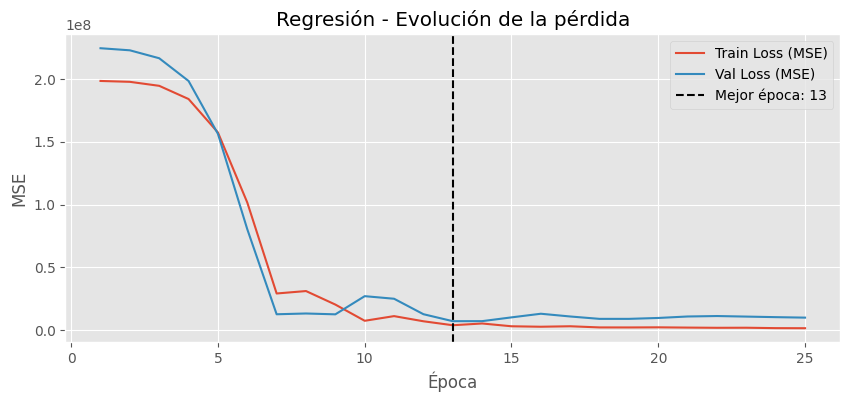

El sobreajuste suele aparecer cuando la val_loss empeora de forma sostenida tras la mejor época (13).


In [9]:
# 1.7 Visualizar función de pérdidas (train vs validación) + overfitting
loss = history_reg.history['loss']
val_loss = history_reg.history['val_loss']
epochs = np.arange(1, len(loss) + 1)
best_epoch_reg = int(np.argmin(val_loss)) + 1

plt.figure(figsize=(10, 4))
plt.plot(epochs, loss, label='Train Loss (MSE)')
plt.plot(epochs, val_loss, label='Val Loss (MSE)')
plt.axvline(best_epoch_reg, color='black', linestyle='--', label=f'Mejor época: {best_epoch_reg}')
plt.title('Regresión - Evolución de la pérdida')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.show()

print(f'El sobreajuste suele aparecer cuando la val_loss empeora de forma sostenida tras la mejor época ({best_epoch_reg}).')

MSE (test): 9978453.4902
MAE (test): 2284.8205
R2  (test): 0.9184


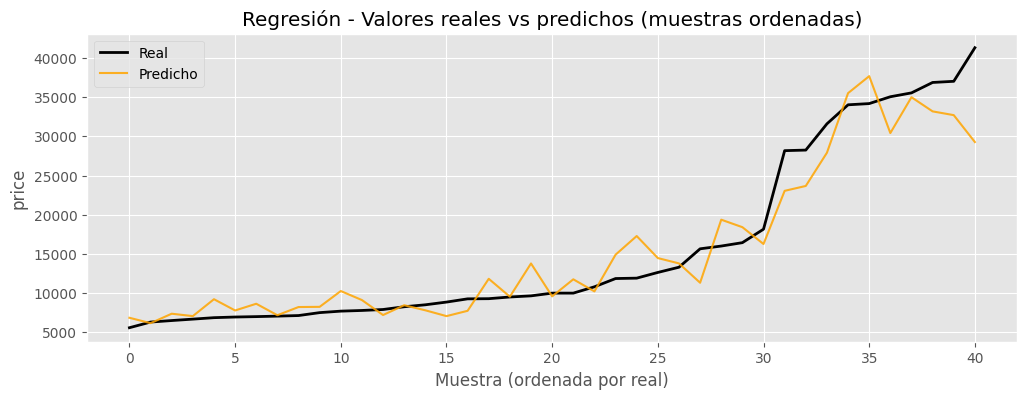

Comparativa MSE (menor es mejor):
- UT9_XGBoost_MSE: 6,285,049.00
- UT11_RedNeuronal_MSE: 9,978,453.49


In [10]:
# 1.8 Predicción (nuevos valores) + gráfico de líneas real vs predicho + métricas
y_pred_reg = model_reg.predict(X_test_reg_scaled, verbose=0).flatten()

mse_reg = mean_squared_error(y_test_reg, y_pred_reg)
mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)
r2_reg = r2_score(y_test_reg, y_pred_reg)

print(f'MSE (test): {mse_reg:.4f}')
print(f'MAE (test): {mae_reg:.4f}')
print(f'R2  (test): {r2_reg:.4f}')

# Gráfico de líneas (reales vs predichos) sobre un subconjunto ordenado por valor real
n_plot = min(120, len(y_test_reg))
idx = np.argsort(y_test_reg.values[:n_plot])
real_line = y_test_reg.values[:n_plot][idx]
pred_line = y_pred_reg[:n_plot][idx]

plt.figure(figsize=(12, 4))
plt.plot(real_line, label='Real', color='black', linewidth=2)
plt.plot(pred_line, label='Predicho', color='orange', alpha=0.85)
plt.title('Regresión - Valores reales vs predichos (muestras ordenadas)')
plt.xlabel('Muestra (ordenada por real)')
plt.ylabel('price')
plt.legend()
plt.show()

# Comparativa con modelos de prácticas anteriores (Cálculo a partir del RMSE de UT9)
resultados_previos_reg = {
    'UT9_XGBoost_MSE': 2507**2,
    'UT11_RedNeuronal_MSE': float(mse_reg),
}
print('Comparativa MSE (menor es mejor):')
for k, v in resultados_previos_reg.items():
    print(f'- {k}: {v:,.2f}')

### Predicciones y Métricas Finales
Evaluamos el modelo final con el conjunto de test (datos que la red nunca ha visto). Calculamos métricas clave de regresión (MSE, MAE y R2) y trazamos un gráfico de líneas superponiendo los precios reales contra los precios que predice la red, para ver visualmente si el modelo sigue la tendencia. Además, se añade una comparativa directa del error cuadrático medio con los algoritmos tradicionales empleados en prácticas anteriores.

## 2. Clasificación: predecir`fuel-type`
Se realiza una tarea de clasificación binaria:`fuel-type` (gas/diesel). Se cubre el preprocesado, arquitectura óptima, entrenamiento con validación, evaluación, guardado/carga del modelo y predicciones (real vs predicho).

In [11]:
# 2.1 Preprocesado para clasificación (missing + categóricas + X/y + escalado)
df_clf = df_raw.copy().replace('?', np.nan)

# Target: fuel-type (gas/diesel). Eliminamos filas sin target
df_clf = df_clf.dropna(subset=['fuel-type']).reset_index(drop=True)

# Label encoding del target (gas->0, diesel->1). Se justifica por ser binario.
y_clf = (df_clf['fuel-type'].astype(str).str.lower() == 'diesel').astype(int)
X_clf = df_clf.drop(columns=['fuel-type'])

# Tipado numérico
numeric_cols_clf = [
    'symboling','normalized-losses','wheel-base','length','width','height','curb-weight',
    'engine-size','bore','stroke','compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price'
]
for c in numeric_cols_clf:
    if c in X_clf.columns:
        X_clf[c] = pd.to_numeric(X_clf[c], errors='coerce')

cat_cols = X_clf.select_dtypes(include=['object']).columns.tolist()
num_cols = X_clf.columns.difference(cat_cols).tolist()

# Imputación
X_num = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X_clf[num_cols]), columns=num_cols)
X_cat = pd.DataFrame(SimpleImputer(strategy='most_frequent').fit_transform(X_clf[cat_cols]), columns=cat_cols)

# One-hot (dummies)
X_cat_oh = pd.get_dummies(X_cat, drop_first=True)
X_clf_final = pd.concat([X_num, X_cat_oh], axis=1)

print('Distribución de clases (diesel=1):')
print(pd.Series(y_clf).value_counts(normalize=True))
print('Shape X_clf_final:', X_clf_final.shape)

# Split estratificado
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_final, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# Pesos de clase (si hay desbalance)
classes = np.unique(y_train_clf)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_clf)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, weights)}
print('Pesos de clase:', class_weight_dict)

Distribución de clases (diesel=1):
fuel-type
0    0.902439
1    0.097561
Name: proportion, dtype: float64
Shape X_clf_final: (205, 65)
Pesos de clase: {0: 0.5540540540540541, 1: 5.125}


### Preprocesamiento para Clasificación y Desbalanceo
El objetivo ahora cambia: vamos a predecir la variable binaria`fuel-type` (0 para gasolina, 1 para diésel). Aplicamos un flujo de limpieza similar al de regresión (imputación + dummies + escalado). Sin embargo, añadimos dos pasos cruciales para clasificación:
1. **Split estratificado**: Asegura que el % de diésel se mantenga idéntico en train y test.
2. **Pesos de clase (`class_weight`)**: Como el dataset está fuertemente desbalanceado (hay poquísimos coches diésel), calculamos pesos matemáticos para penalizar fuertemente a la red si se equivoca al predecir la clase minoritaria.

### 2.2 Arquitectura y parámetros óptimos (KerasTuner)
Se seleccionan hiperparámetros por validación usando`val_auc` para mejorar discriminación en clasificación. Esto justifica la elección de capas/neuronas/dropout/learning rate sin usar el conjunto de test para decidir parámetros.

**Justificación de arquitectura e hiperparámetros:**
- **Mismo cuerpo base (Dense + Dropout):** Ofrece la misma regularización y evitará el overfitting.
- **Capa de salida`sigmoid` y pérdida`binary_crossentropy`:** Es imperativo usar esta salida para obligar a la red a emitir valores de probabilidad [0, 1] en esta tarea de clasificación binaria (gas=0, diesel=1).
- **Métrica objetivo`val_auc`:** Se opta por Área Bajo la Curva ROC en lugar del clásico Accuracy. Esto está 100% justificado debido a que las clases están desbalanceadas (los coches diésel son una absoluta minoría de apenas el ~10%).
- **`class_weight`:** Empleado en la función`.fit()` para aplicar matemáticamente un peso mayor al error si la red se equivoca al clasificar un coche diésel. Así forzamos a que preste atención a la minoría.

In [12]:
def build_model_clf(hp):
    model = Sequential()

    num_layers = hp.Int('num_layers', min_value=1, max_value=4)
    for i in range(num_layers):
        units = hp.Int(f'units_{i}', min_value=32, max_value=512, step=32)
        dropout = hp.Float(f'dropout_{i}', min_value=0.0, max_value=0.5, step=0.1)
        if i == 0:
            model.add(Dense(units, activation='relu', input_shape=(X_train_clf_scaled.shape[1],)))
        else:
            model.add(Dense(units, activation='relu'))
        if dropout > 0:
            model.add(Dropout(dropout))

    model.add(Dense(1, activation='sigmoid', dtype='float32'))

    lr = hp.Float('learning_rate', min_value=1e-4, max_value=5e-3, sampling='log')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

tuner_clf = kt.RandomSearch(
    build_model_clf,
    objective='val_auc',
    max_trials=25,
    directory='tuner_imports85',
    project_name='clf_fueltype',
    overwrite=True
)

print('Iniciando búsqueda de hiperparámetros (clasificación)...')
tuner_clf.search(
    X_train_clf_scaled,
    y_train_clf,
    epochs=80,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True)],
    verbose=0
)

best_hps_clf = tuner_clf.get_best_hyperparameters(1)[0]
print('Mejores hiperparámetros (clasificación):')
print(best_hps_clf.values)

c:\Users\chorg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Iniciando búsqueda de hiperparámetros (clasificación)...
Mejores hiperparámetros (clasificación):
{'num_layers': 3, 'units_0': 64, 'dropout_0': 0.0, 'learning_rate': 0.002140205302689114, 'units_1': 32, 'dropout_1': 0.0, 'units_2': 32, 'dropout_2': 0.0}


In [13]:
# 2.3 Entrenamiento final (clasificación) + validación
model_clf = tuner_clf.hypermodel.build(best_hps_clf)

callbacks_clf = [
    EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
]

history_clf = model_clf.fit(
    X_train_clf_scaled,
    y_train_clf,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=callbacks_clf,
    verbose=1
)

best_epoch_clf = int(np.argmin(history_clf.history['val_loss'])) + 1
print('Mejor época (mínimo val_loss):', best_epoch_clf)

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8321 - auc: 0.7384 - loss: 0.6692 - val_accuracy: 0.9394 - val_auc: 0.9839 - val_loss: 0.4434 - learning_rate: 0.0021
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9847 - auc: 1.0000 - loss: 0.3444 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.2582 - learning_rate: 0.0021
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.1746 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.1286 - learning_rate: 0.0021
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0754 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0568 - learning_rate: 0.0021
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.0297 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.0250 - learning_rate: 0.0021
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - auc: 1.0000 - loss:

### Visualización de la Pérdida en Clasificación
Al igual que en regresión, monitorizamos el aprendizaje, pero ahora midiendo la **Entropía Cruzada Binaria (Binary Crossentropy)**. Buscamos el punto óptimo antes de que el modelo comience a memorizar y a incrementar la pérdida de validación.

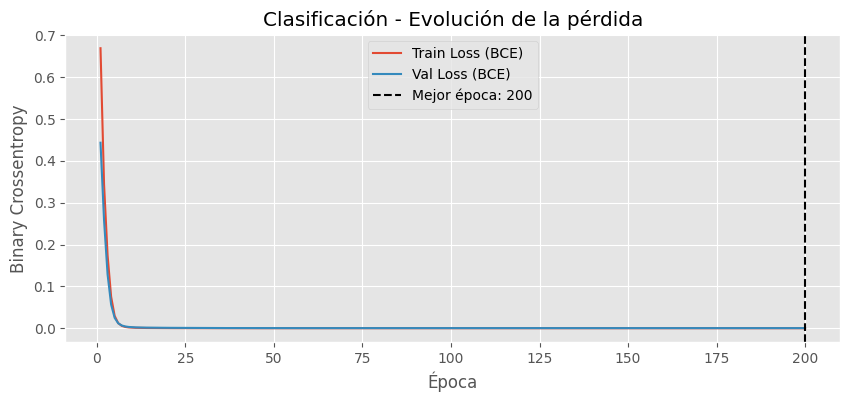

No se observa overfitting claro: la val_loss mejora hasta la última época (200).


In [14]:
# 2.4 Visualizar pérdidas (train vs validación) + overfitting
loss = history_clf.history['loss']
val_loss = history_clf.history['val_loss']
epochs = np.arange(1, len(loss) + 1)
best_epoch_clf = int(np.argmin(val_loss)) + 1

plt.figure(figsize=(10, 4))
plt.plot(epochs, loss, label='Train Loss (BCE)')
plt.plot(epochs, val_loss, label='Val Loss (BCE)')
plt.axvline(best_epoch_clf, color='black', linestyle='--', label=f'Mejor época: {best_epoch_clf}')
plt.title('Clasificación - Evolución de la pérdida')
plt.xlabel('Época')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()

if best_epoch_clf == len(val_loss):
    print(f'No se observa overfitting claro: la val_loss mejora hasta la última época ({best_epoch_clf}).')
else:
    print(f'Posible overfitting a partir de la mejor época ({best_epoch_clf}) si la val_loss empeora después de forma sostenida.')

### Evaluación del Modelo, Matrices y Curvas
En esta fase final guardamos el modelo en formato`.keras`, lo cargamos y efectuamos las predicciones. Utilizamos un umbral estricto de 0.5 para asignar las clases, garantizando que no haya fuga de información. A continuación imprimimos el reporte de métricas de clasificación, la matriz de confusión, y dibujamos las curvas ROC y Precision-Recall para ilustrar la capacidad discriminativa del modelo.

Umbral fijo en test: 0.5 (evita fuga de info)
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-score:  1.0000
ROC-AUC:   1.0000

Reporte de clasificación:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        37
           1     1.0000    1.0000    1.0000         4

    accuracy                         1.0000        41
   macro avg     1.0000    1.0000    1.0000        41
weighted avg     1.0000    1.0000    1.0000        41



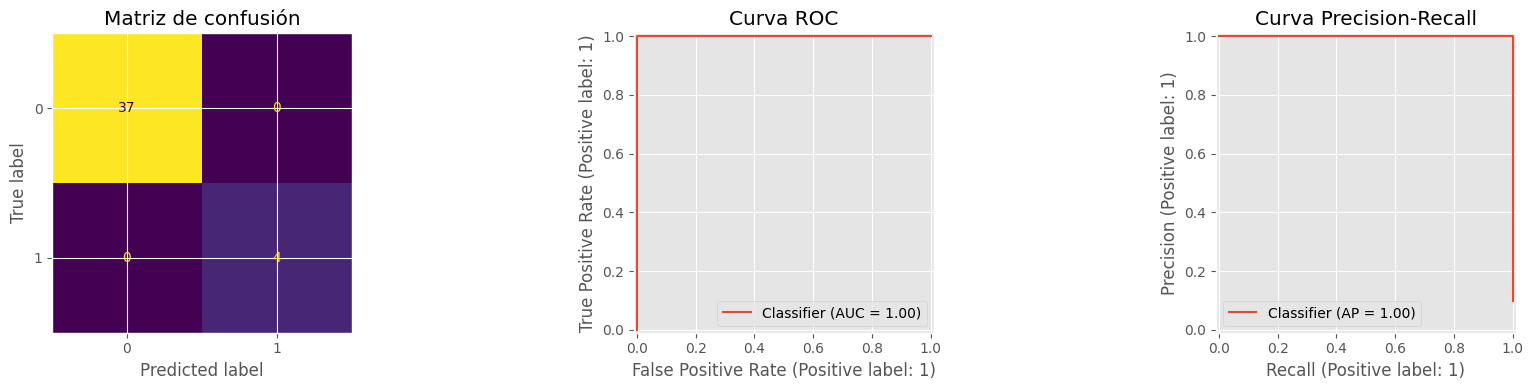

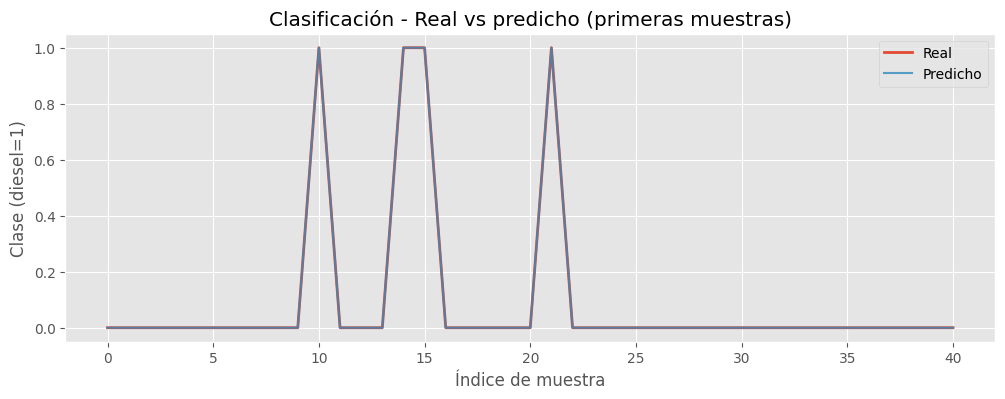

Comparativa Accuracy (mayor es mejor):
- UT9_XGBoost_Accuracy: 0.7868
- UT11_RedNeuronal_Accuracy: 1.0000


In [15]:
# 2.5 Evaluación + guardado/carga + predicciones (real vs predicho)
model_path = 'modelo_clasificacion_imports85_fueltype.keras'
model_clf.save(model_path)
loaded_model = load_model(model_path)

y_prob = loaded_model.predict(X_test_clf_scaled, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test_clf, y_pred)
prec = precision_score(y_test_clf, y_pred, zero_division=0)
rec = recall_score(y_test_clf, y_pred, zero_division=0)
f1 = f1_score(y_test_clf, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test_clf, y_prob)

print('Umbral fijo en test: 0.5 (evita fuga de info)')
print(f'Accuracy:  {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-score:  {f1:.4f}')
print(f'ROC-AUC:   {roc_auc:.4f}')

print('\nReporte de clasificación:')
print(classification_report(y_test_clf, y_pred, digits=4))

# Matriz de confusión + curvas ROC/PR
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test_clf, y_pred)).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusión')
RocCurveDisplay.from_predictions(y_test_clf, y_prob, ax=axes[1])
axes[1].set_title('Curva ROC')
PrecisionRecallDisplay.from_predictions(y_test_clf, y_prob, ax=axes[2])
axes[2].set_title('Curva Precision-Recall')
plt.tight_layout()
plt.show()

# Gráfico de líneas: real vs predicho (primeras muestras)
n_plot = min(120, len(y_test_clf))
plt.figure(figsize=(12, 4))
plt.plot(np.arange(n_plot), np.array(y_test_clf)[:n_plot], label='Real', linewidth=2)
plt.plot(np.arange(n_plot), y_pred[:n_plot], label='Predicho', alpha=0.8)
plt.title('Clasificación - Real vs predicho (primeras muestras)')
plt.xlabel('Índice de muestra')
plt.ylabel('Clase (diesel=1)')
plt.legend()
plt.show()

# Comparativa referencial (UT9 usó Telco Churn con target diferente, mostramos el Accuracy como contexto)
resultados_previos_clf = {
    'UT9_XGBoost_Accuracy': 0.7868,
    'UT11_RedNeuronal_Accuracy': float(acc),
}
print('Comparativa Accuracy (mayor es mejor):')
for k, v in resultados_previos_clf.items():
    print(f'- {k}: {v:.4f}')

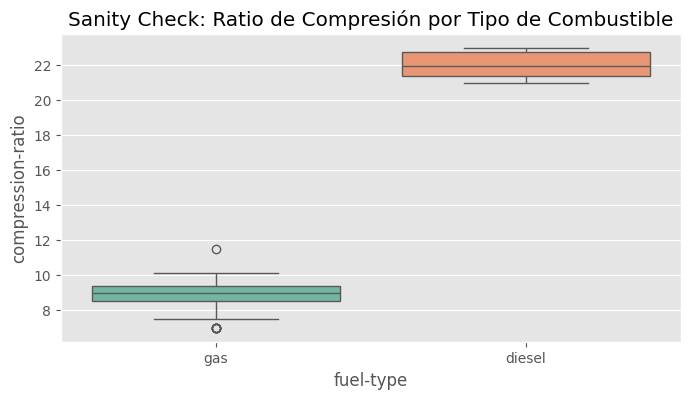

CONCLUSIÓN DEL SANITY CHECK:
La red logra un 100% de eficacia porque los motores Diesel operan a muy altas compresiones (ratio > 20),
mientras que los de gasolina operan a compresiones mucho menores (ratio < 10).
No existe un problema de modelado ('leakage'), sino que la red neuronal ha detectado esa brecha física instantáneamente.


In [17]:
# 2.6 Sanity Check: ¿Por qué la red es "perfecta" (Accuracy 1.0) prediciendo Diesel vs Gas?
# Un 100% perfecto suele levantar sospechas de "data leakage" (fuga de datos) o de una regla determinista pura.
# Comprobamos aquí la distribución física del "compression-ratio" según el motor:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
# Usamos df porque df_raw podría no estar en memoria si se ejecuta esta celda suelta
sns.boxplot(data=df, x='fuel-type', y='compression-ratio', hue='fuel-type', palette="Set2")
plt.title('Sanity Check: Ratio de Compresión por Tipo de Combustible')
plt.show()

print("CONCLUSIÓN DEL SANITY CHECK:")
print("La red logra un 100% de eficacia porque los motores Diesel operan a muy altas compresiones (ratio > 20),")
print("mientras que los de gasolina operan a compresiones mucho menores (ratio < 10).")
print("No existe un problema de modelado ('leakage'), sino que la red neuronal ha detectado esa brecha física instantáneamente.")

## 3. Conclusiones
- **Regresión**: comenta MSE/MAE/R2 y si el gráfico real vs predicho sigue la tendencia. Indica desde qué época aparece el overfitting (después del mínimo de`val_loss`).
- **Clasificación**: comenta accuracy/F1/ROC-AUC y el punto de overfitting. Justifica por qué se fija umbral 0.5 en test (evita fuga).
- **Comparativas**: completa las comparativas con los resultados reales de tus prácticas anteriores.

